In [1]:
# ============================================================
# Cell 1: Import Libraries and Environment Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno  # Required for missing data visualization
import os

# Configure inline plotting for VS Code/Jupyter
%matplotlib inline
sns.set(style="whitegrid")

# 1. Path Management
# Since the notebook is in /notebooks, we move up one level and then into /datasets
data_folder = os.path.join('..', 'datasets')
file_name = 'healthcare-dataset-stroke-data.csv'
local_path = os.path.join(data_folder, file_name)

# 2. Data Loading Logic
# Note: Final submission requires public URL loading for Google Colab [cite: 119]
if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f"Success: Dataset loaded from local path: {local_path}")
else:
    print("Warning: Local file not found. Check your directory structure.")
    # Placeholder for GitHub/Public URL for final Colab deployment [cite: 119, 125]
    # url = "https://raw.githubusercontent.com/[User]/[Repo]/main/datasets/healthcare-dataset-stroke-data.csv"
    # df = pd.read_csv(url)

# 3. Initial Data Inspection
print(f"Dataset Shape: {df.shape}")
df.head()

Success: Dataset loaded from local path: ..\datasets\healthcare-dataset-stroke-data.csv
Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

--- Missing Value Count ---
id                     0
gender                 0
age                    0
hypertension           

<Figure size 1000x400 with 0 Axes>

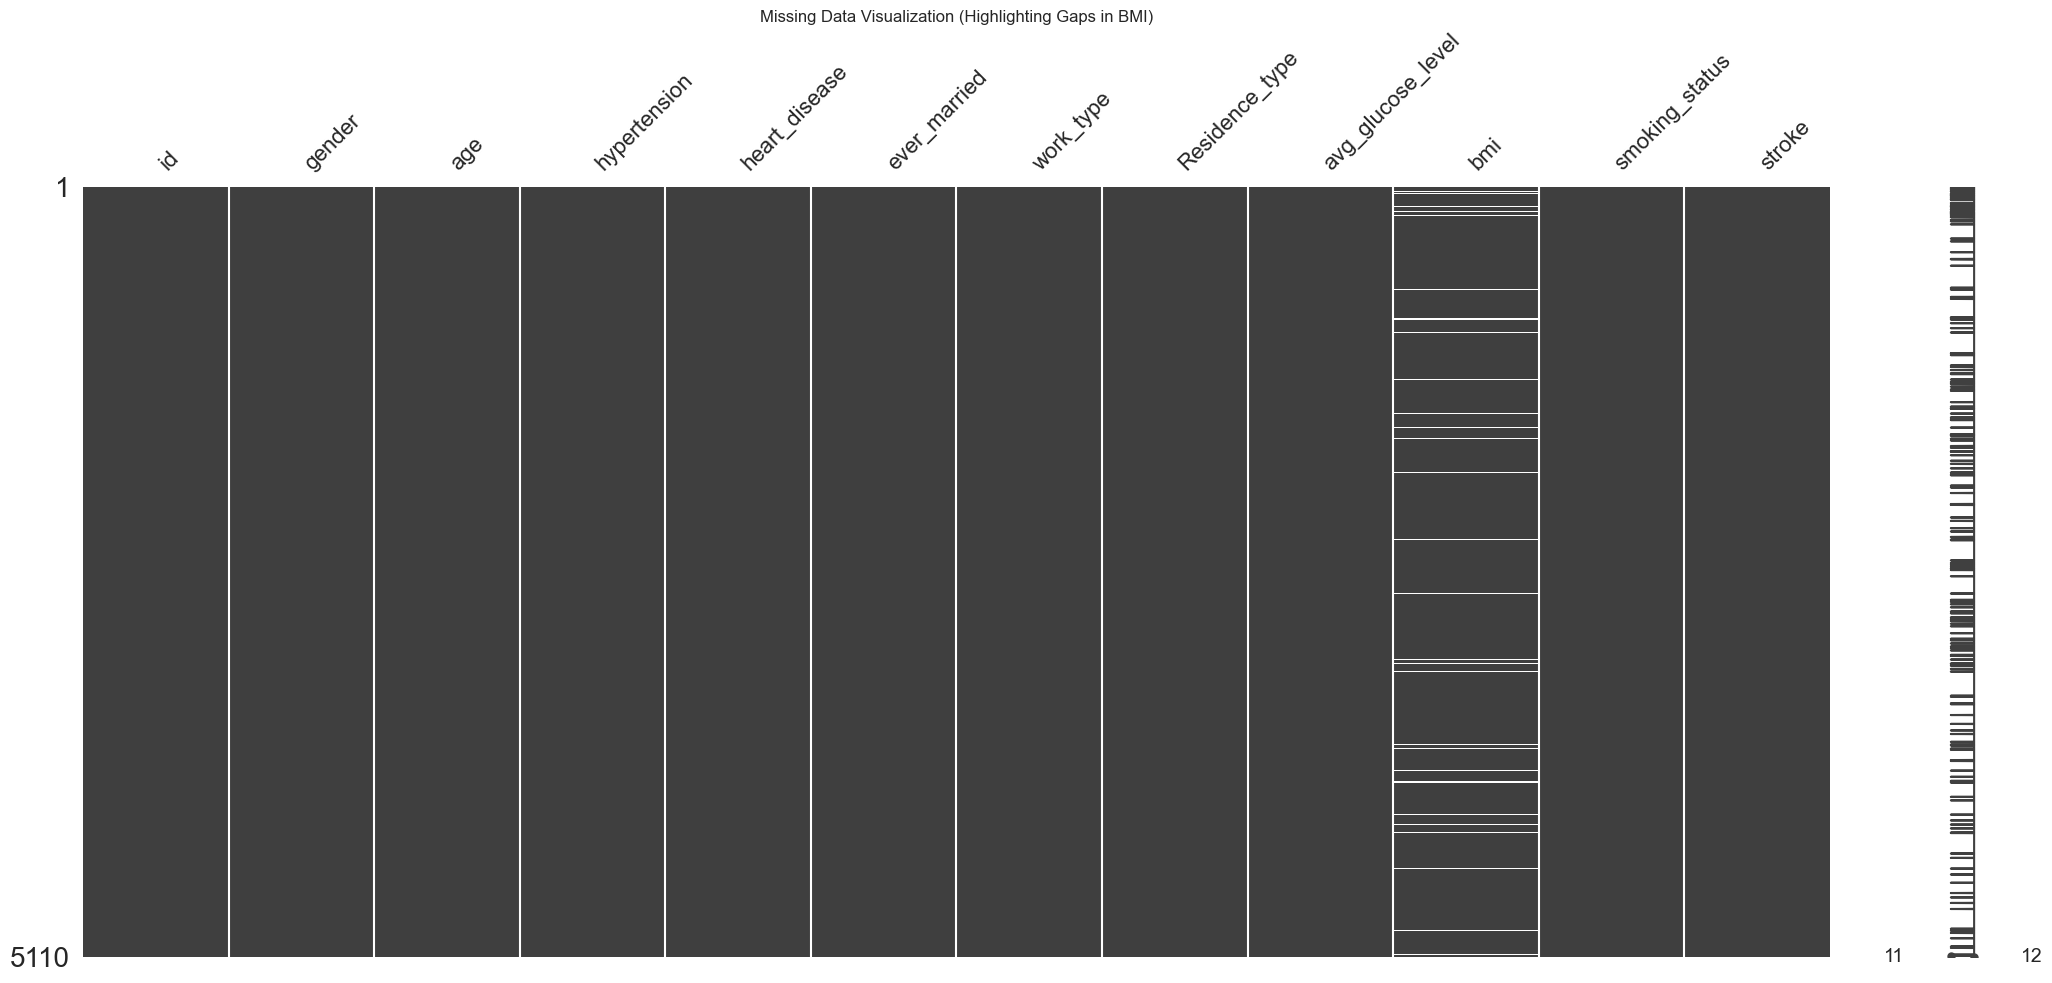

In [2]:
# ============================================================
# Cell 2: Missing Value Identification
# ============================================================
print("--- Data Information ---")
print(df.info())

print("\n--- Missing Value Count ---")
print(df.isnull().sum())

# Visualizing missing values using missingno matrix
# This fulfills the requirement to identify data gaps for Imputation 
plt.figure(figsize=(10, 4))
msno.matrix(df)
plt.title("Missing Data Visualization (Highlighting Gaps in BMI)")
plt.show()

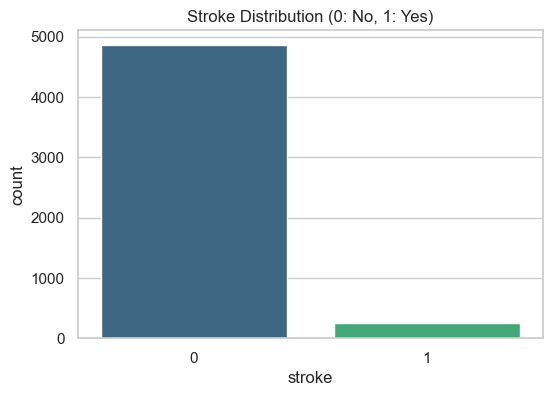

Stroke Incidence Rate: 4.87%


In [3]:
# ============================================================
# Cell 3: Target Variable Distribution (Stroke)
# ============================================================
plt.figure(figsize=(6, 4))
# sns.countplot(x='stroke', data=df, palette='viridis')
sns.countplot(x='stroke', data=df, hue='stroke', palette='viridis', legend=False)
plt.title('Stroke Distribution (0: No, 1: Yes)')
plt.show()

# Calculate the imbalance percentage
stroke_pct = df['stroke'].value_counts(normalize=True) * 100
print(f"Stroke Incidence Rate: {stroke_pct[1]:.2f}%")

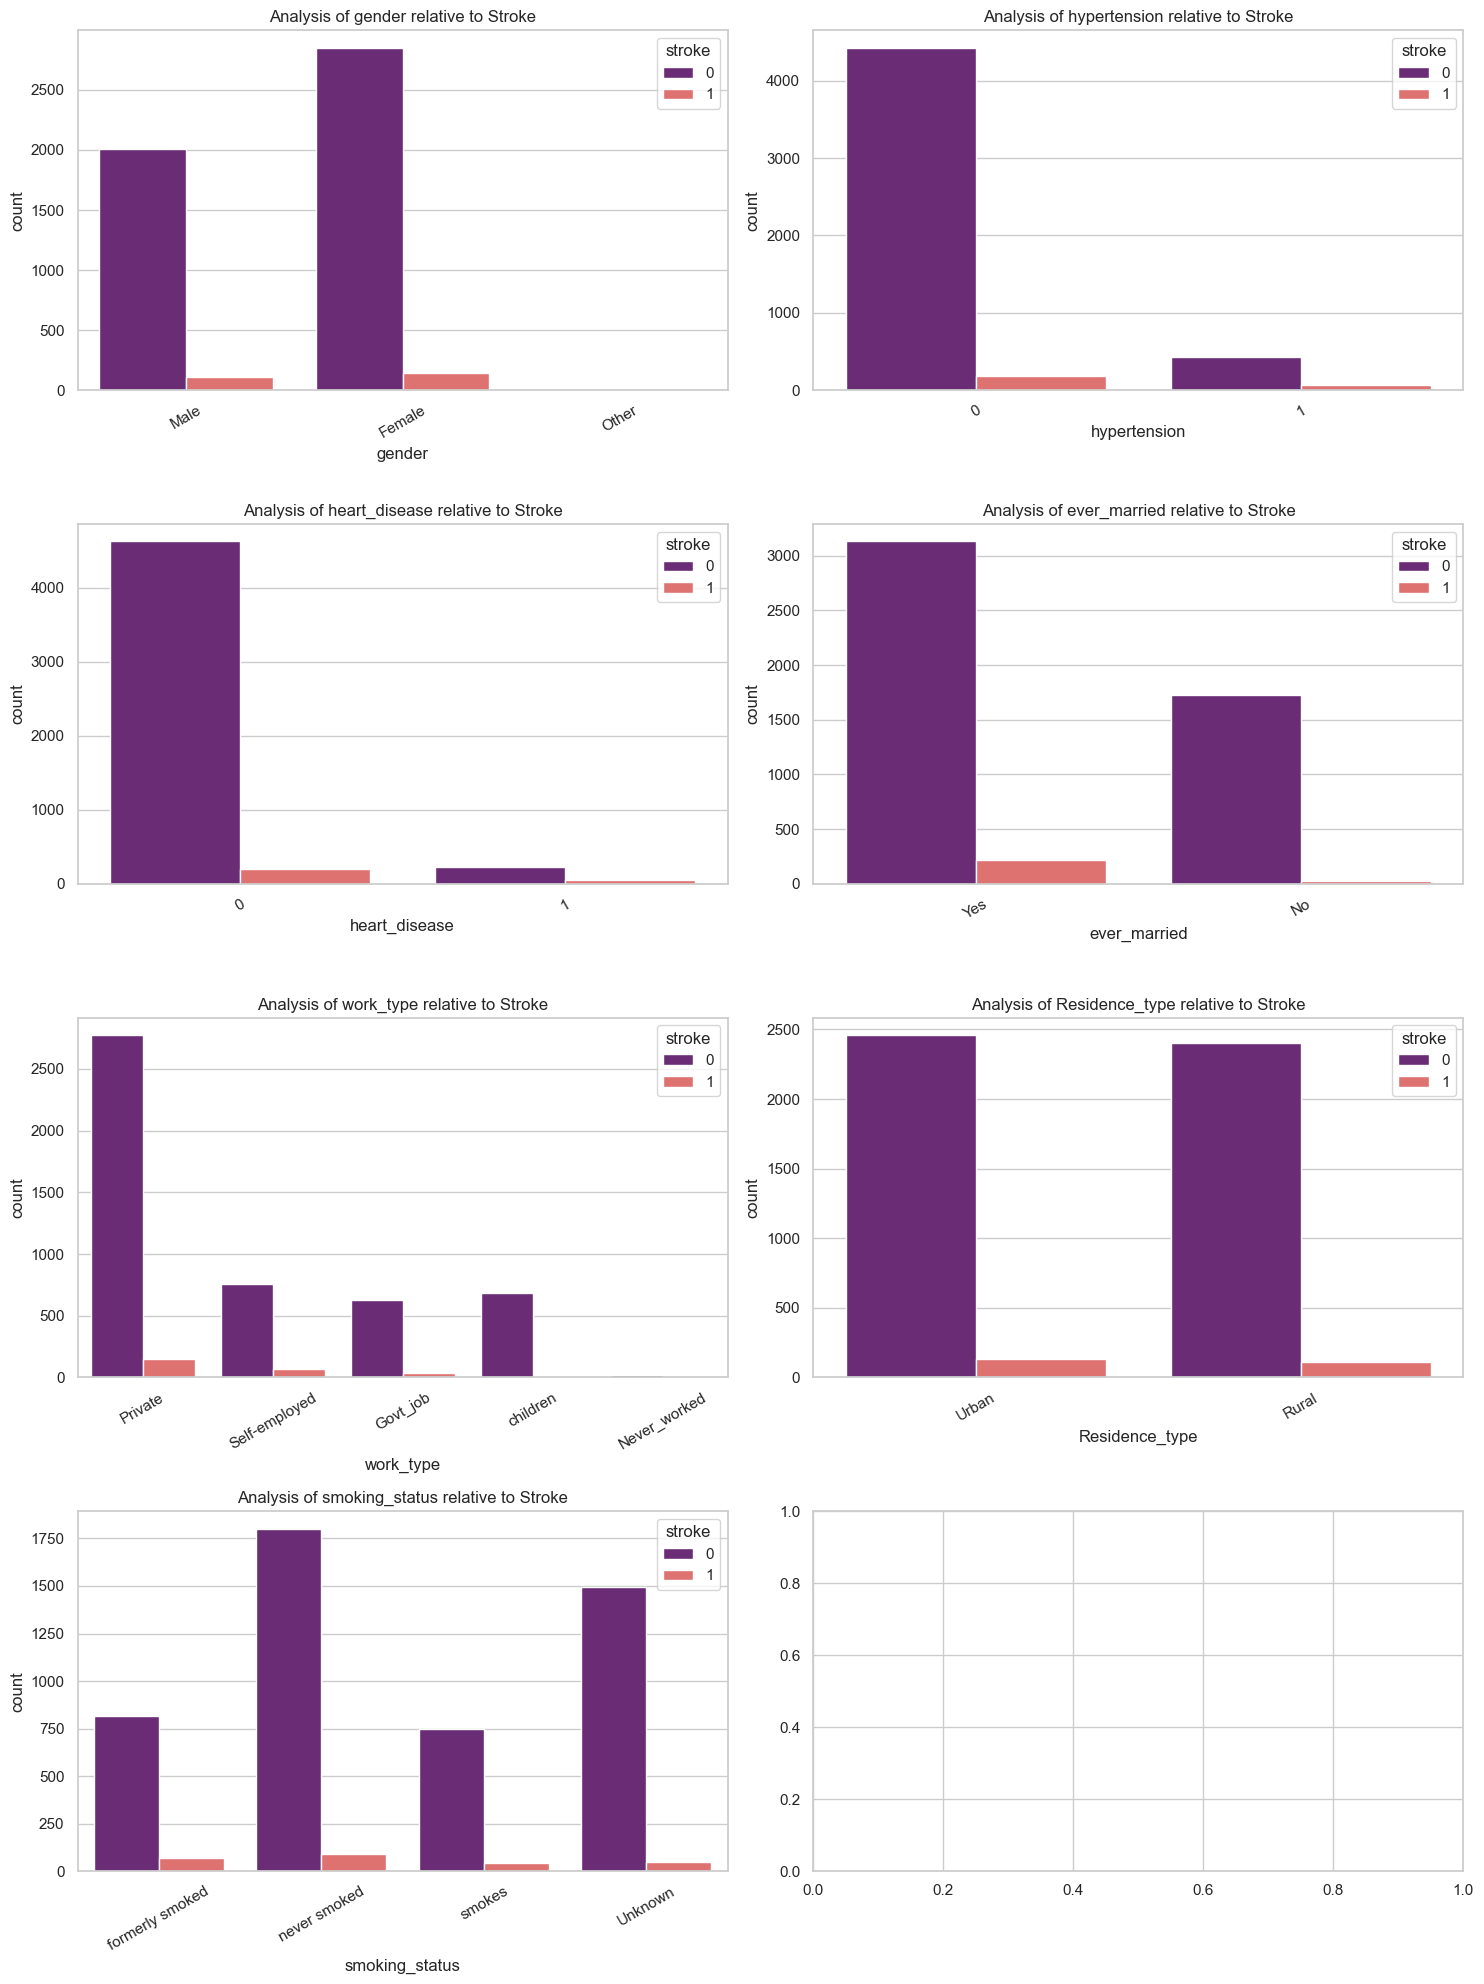

In [4]:
# ============================================================
# Cell 4: Categorical Features vs Target
# ============================================================
# Identifying columns that require Encoding 
cat_features = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='stroke', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Analysis of {col} relative to Stroke')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

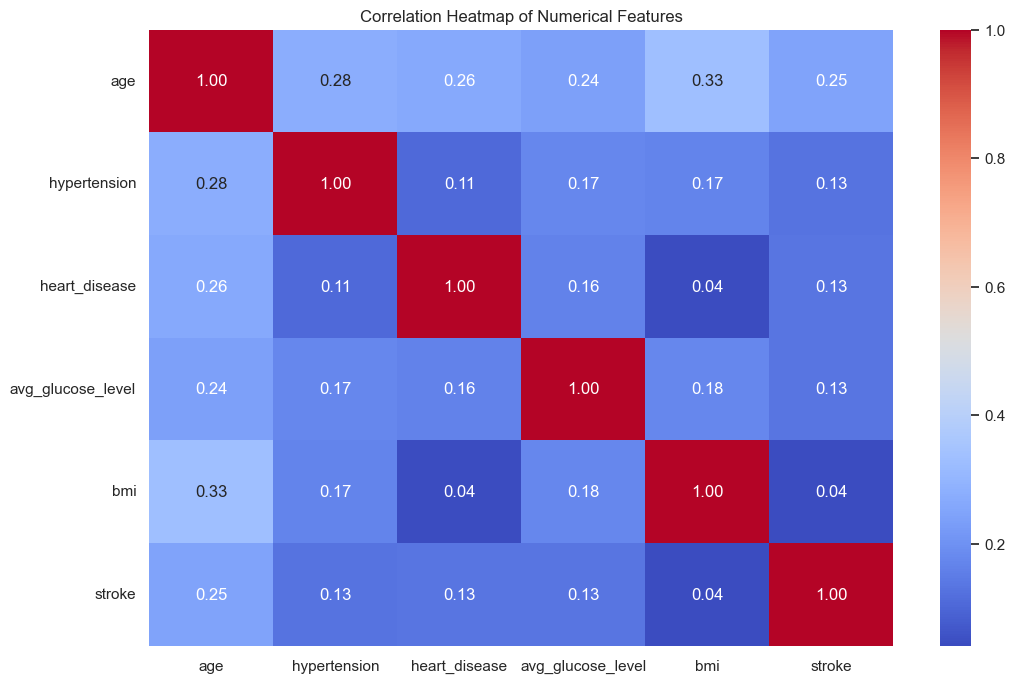

In [5]:
# ============================================================
# Cell 5: Numeric Feature Correlation Matrix
# ============================================================
plt.figure(figsize=(12, 8))
# Drop 'id' as it has no predictive value
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()